# Newman-Watts model at fixed expected shortcut count $c$

Study of the purification times and tableau density on the **Newman-Watts**
graph: a **cycle backbone** on $n$ vertices plus Erdős-Rényi shortcuts, where each of
the $n(n-3)/2$ non-backbone pairs is added independently with probability
$\beta$, under the constraint

$$\beta \cdot \frac{n(n-3)}{2} = c, \qquad c \in [10^{-2}, 10^{3}] \text{ (log scale)},$$

so $c$ is the **expected number of shortcuts** and $\beta = 2c/(n(n-3))$ is set
per system size. Sweeping $c$ interpolates the geometry from the bare cycle
(quasi-1D, $c \to 0$) toward a dense all-to-all-like graph ($c \gg n$), at fixed
graph "shortcut budget" rather than fixed $\beta$.

Tracked per trajectory (both pictures, `until_purified`, `hybrid=True`):
**`purified_at_layer`** ($\tau_\mathrm{full}$ for `purification`, $\tau_p$ for
`single_ref`) and **`mean_active_generators`** ($\bar a$).

**Architecture.** The NW graph is irregular (no 1-factorization), so gating is
`random_pool`, namely $n/2$ edges drawn with replacement per layer, which keeps the
gate:measurement pacing of brickwork, with `bernoulli` measurements at rate
$p$. Each $(n, c)$ cell averages over `N_GRAPHS` independent **shortcut
realizations** (quenched disorder) times `SEEDS` circuit/measurement seeds.

**Caveat at large $c$:** when $c > n(n-3)/2$, $\beta$ clamps at 1 (the graph
saturates to the complete graph) and the constraint cannot be met, so the run
prints a clamp table; interpret those points as "complete graph", not NW.

Run with `PRODUCTION = False` first (a ~2-minute smoke pass over the identical
code path), then flip to `True`. The run is **chunked + resumable**: one on-disk
`Study` per (picture, $n$, $c$); finished chunks are skipped on re-run.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sparsegf2.circuits import CircuitConfig, from_networkx, simulate
from sparsegf2.analysis import Study

plt.rcParams["figure.dpi"] = 115
plt.rcParams["axes.grid"] = True
plt.rcParams["savefig.bbox"] = "tight"

PRODUCTION = False

if PRODUCTION:
    N_VALS = [32, 64, 128]
    C_VALS = sorted(np.round(np.logspace(-2, 3, 11), 4).tolist())   # 0.01 .. 1000
    P_VALS = [0.10, 0.20, 0.30]
    N_GRAPHS = 8          # shortcut realizations per (n, c)
    SEEDS = 40            # circuit/measurement seeds per realization
    DEPTH_FACTOR = 30
else:
    N_VALS = [16, 24]
    C_VALS = [0.1, 1.0, 10.0, 100.0]
    P_VALS = [0.20, 0.35]
    N_GRAPHS = 2
    SEEDS = 4
    DEPTH_FACTOR = 20

PICTURES = ["purification", "single_ref"]
OUT = Path("runs/newman_watts_c")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)


def beta_for(n, c):
    """beta from the constraint beta * n(n-3)/2 = c, clamped to [0, 1]."""
    return min(1.0, 2.0 * c / (n * (n - 3)))


def nw_graph(n, c, graph_seed):
    """Cycle backbone + ER(beta) shortcuts over the n(n-3)/2 non-backbone pairs."""
    beta = beta_for(n, c)
    rng = np.random.default_rng(graph_seed)
    g = nx.cycle_graph(n)
    for u in range(n):
        for v in range(u + 1, n):
            if (v - u) in (1, n - 1):          # backbone edge
                continue
            if rng.random() < beta:
                g.add_edge(u, v)
    return from_networkx(g, name=f"gs{graph_seed}")


def base_config(n, c, picture):
    return CircuitConfig(
        graph_spec=nw_graph(n, c, 0), n=n, p=P_VALS[0], picture=picture,
        gating_mode="random_pool", measurement_mode="bernoulli",
        depth_mode="until_purified", depth_factor=DEPTH_FACTOR, hybrid=True,
    )


# clamp table: where the constraint saturates
print("beta(n, c): '1.0!' marks the clamp (graph = complete, constraint unmet):")
tab = pd.DataFrame({n: {c: (f"{beta_for(n, c):.2g}" + ("!" if beta_for(n, c) >= 1 else ""))
                        for c in C_VALS} for n in N_VALS})
tab.index.name = "c"
print(tab)
n_chunks = len(PICTURES) * len(N_VALS) * len(C_VALS)
print(f"\nchunks: {n_chunks} | cells/chunk: {len(P_VALS) * N_GRAPHS * SEEDS} | "
      f"total cells: {n_chunks * len(P_VALS) * N_GRAPHS * SEEDS:,} | cores: {os.cpu_count()}")


beta(n, c): '1.0!' marks the clamp (graph = complete, constraint unmet):
            16      24
c                     
0.1    0.00096  0.0004
1.0     0.0096   0.004
10.0     0.096    0.04
100.0     0.96     0.4

chunks: 16 | cells/chunk: 16 | total cells: 256 | cores: 8


## 1. Calibration: project the wall-clock before committing

Times one cheap (high-$p$, large-$c$) and one expensive (low-$p$, smallest-$c$ =
quasi-1D, slowest to purify) trajectory at the largest $n$, then scales by the
cell count. The low-$c$, low-$p$ cells dominate: a near-cycle graph purifies
slowly, so those cells run toward the `DEPTH_FACTOR * n` cap.


In [2]:
import time

def time_cell(n, c, p, picture):
    cfg = CircuitConfig(
        graph_spec=nw_graph(n, c, 0), n=n, p=p, picture=picture,
        gating_mode="random_pool", measurement_mode="bernoulli",
        depth_mode="until_purified", depth_factor=DEPTH_FACTOR, hybrid=True)
    t0 = time.perf_counter()
    rec = simulate(cfg, sample_seed=0)
    return time.perf_counter() - t0, rec

n_big = N_VALS[-1]
_ = time_cell(N_VALS[0], C_VALS[0], max(P_VALS), "purification")     # JIT warm
t_cheap, _ = time_cell(n_big, max(C_VALS), max(P_VALS), "purification")
t_dear, rec = time_cell(n_big, min(C_VALS), min(P_VALS), "purification")
state = "censored (full cap)" if rec.purified_at_layer is None else f"tau={rec.purified_at_layer}"
print(f"n={n_big}: cheap cell {t_cheap:.2f} s | expensive cell {t_dear:.2f} s ({state})")
cells_total = len(PICTURES) * len(N_VALS) * len(C_VALS) * len(P_VALS) * N_GRAPHS * SEEDS
par = max(os.cpu_count() - 1, 1)
print(f"projected wall-clock on {os.cpu_count()} cores: "
      f"{cells_total * t_cheap / par / 3600:.1f} h (best) ... "
      f"{cells_total * 0.5 * (t_cheap + t_dear) / par / 3600:.1f} h (typical)")


n=24: cheap cell 0.00 s | expensive cell 0.00 s (tau=23)
projected wall-clock on 8 cores: 0.0 h (best) ... 0.0 h (typical)


## 2. The run: one resumable chunk per (picture, $n$, $c$)

Within a chunk the grid is `p` × `N_GRAPHS` shortcut realizations (the rows'
`graph_spec` column records the realization, e.g. `gs3`), × `SEEDS` circuit
seeds. Realization `gs` uses graph seed `gs`, fully reproducible.


In [3]:
studies = {}
for pic in PICTURES:
    for n in N_VALS:
        for c in C_VALS:
            d = OUT / f"{pic}_n{n}_c{c:g}"
            if (d / "rows.parquet").exists():
                studies[(pic, n, c)] = Study.open(d)
                print(f"[resume] {d.name} ({len(studies[(pic, n, c)])} rows)")
                continue
            print(f"[run]    {d.name}")
            graphs = [nw_graph(n, c, gs) for gs in range(N_GRAPHS)]
            studies[(pic, n, c)] = Study.run(
                d, base_config(n, c, pic),
                grid={"p": P_VALS, "graph_spec": graphs},
                seeds=SEEDS, save_tableaux=False, n_jobs=-1, progress=True,
            )
print("all chunks present")


[run]    purification_n16_c0.1


study:   0%|          | 0/16 [00:00<?, ?step/s]

[run]    purification_n16_c1


study:   0%|          | 0/16 [00:00<?, ?step/s]

[run]    purification_n16_c10


...

[run]    single_ref_n24_c10


study:   0%|          | 0/16 [00:00<?, ?step/s]

[run]    single_ref_n24_c100


study:   0%|          | 0/16 [00:00<?, ?step/s]

all chunks present


## 3. Aggregate: censoring-aware statistics over disorder × trajectories

Per $(picture, n, c, p)$, pooling all `N_GRAPHS × SEEDS` trajectories (i.i.d.
draws of the joint shortcut-disorder + measurement-randomness ensemble):
fraction purified within the cap, mean/SEM and median/IQR of $\tau$ over the
purified trajectories, and mean/SEM of $\bar a$.


In [4]:
frames = []
for (pic, n, c), s in studies.items():
    f = pd.DataFrame(s.rows)
    f["n"], f["c"] = n, c
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
df["purified"] = df["purified_at_layer"].notna()
df["beta"] = [beta_for(n, c) for n, c in zip(df["n"], df["c"])]

agg = (
    df.groupby(["picture", "n", "c", "p"], as_index=False)
      .agg(samples=("sample_seed", "size"),
           frac_purified=("purified", "mean"),
           mean_tau=("purified_at_layer", lambda s: s.dropna().mean()),
           sem_tau=("purified_at_layer", lambda s: s.dropna().sem()),
           median_tau=("purified_at_layer", lambda s: s.dropna().median()),
           mean_abar=("mean_active_generators", "mean"),
           sem_abar=("mean_active_generators", "sem"),
           beta=("beta", "first"))
)
agg.to_csv(OUT / "aggregate.csv", index=False)
print(f"{len(df):,} trajectories -> {len(agg)} cells; saved {OUT / 'aggregate.csv'}")
agg.head(6)


256 trajectories -> 32 cells; saved runs/newman_watts_c/aggregate.csv

,picture,n,c,p,samples,frac_purified,mean_tau,sem_tau,median_tau,mean_abar,sem_abar,beta
0,purification,16,0.1,0.20,8,1.0,18.500,1.782855,17.5,6.264435,0.135299,0.000962
1,purification,16,0.1,0.35,8,1.0,11.750,0.619620,12.5,4.536058,0.109400,0.000962
2,purification,16,1.0,0.20,8,1.0,23.750,3.260970,24.0,7.561603,0.435491,0.009615
3,purification,16,1.0,0.35,8,1.0,11.500,1.336306,11.0,5.377297,0.229565,0.009615
4,purification,16,10.0,0.20,8,1.0,26.625,2.725131,28.0,9.454719,0.516779,0.096154
5,purification,16,10.0,0.35,8,1.0,14.000,1.558387,13.0,6.242464,0.264185,0.096154


## 4. Purification time vs $c$

$\tau$ against the shortcut budget $c$ (log-$x$, log-$y$), one panel per $p$,
curves per $n$. Hollow markers = censored (fraction purified < 0.99: the mean is
a lower bound). Adding shortcuts speeds purification at fixed $p$, since the geometry
crosses from quasi-1D toward all-to-all.


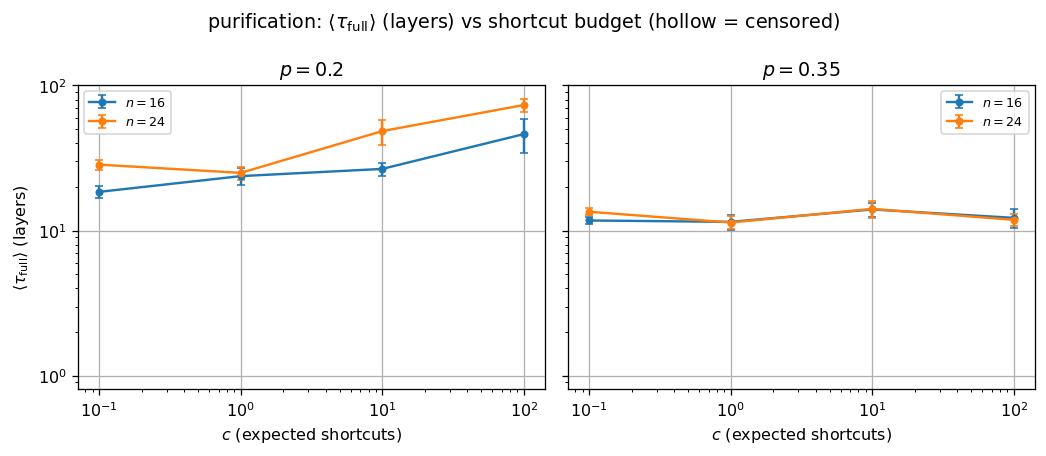

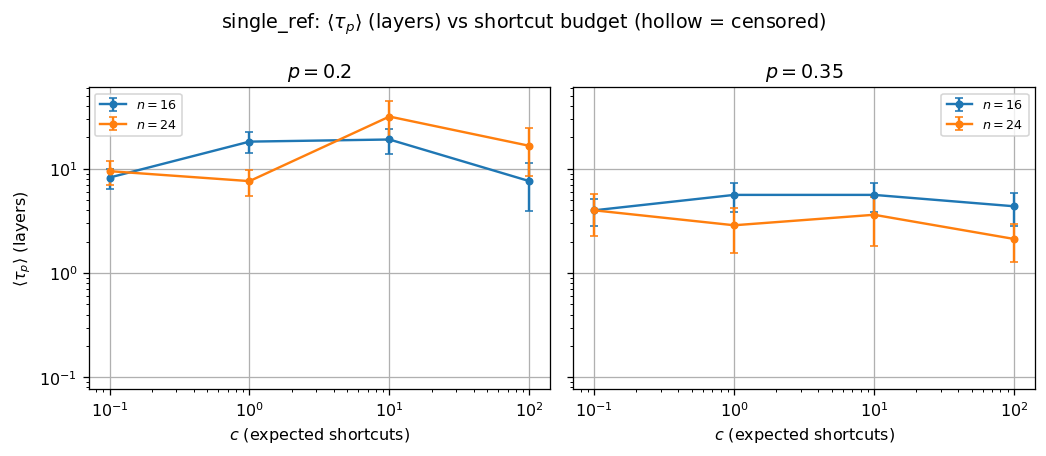

In [5]:
def plot_vs_c(pic, ycol, yerr, ylabel, fname, logy=True, censor_aware=True):
    fig, axes = plt.subplots(1, len(P_VALS), figsize=(4.6 * len(P_VALS), 4),
                             sharey=True, squeeze=False)
    for ax, p in zip(axes[0], P_VALS):
        sub_p = agg[(agg["picture"] == pic) & (agg["p"] == p)]
        for i, (n_val, sub) in enumerate(sub_p.groupby("n")):
            col = f"C{i}"
            if censor_aware:
                ok = sub[sub["frac_purified"] >= 0.99]
                cen = sub[(sub["frac_purified"] < 0.99) & sub[ycol].notna()]
                ax.errorbar(ok["c"], ok[ycol], yerr=ok[yerr], marker="o", ms=4,
                            capsize=2.5, color=col, label=f"$n={n_val}$")
                ax.errorbar(cen["c"], cen[ycol], yerr=cen[yerr], marker="o", ms=4,
                            mfc="white", lw=0, elinewidth=1.2, capsize=2.5, color=col)
            else:
                ax.errorbar(sub["c"], sub[ycol], yerr=sub[yerr], marker="o", ms=4,
                            capsize=2.5, color=col, label=f"$n={n_val}$")
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        ax.set(xlabel="$c$ (expected shortcuts)", title=f"$p={p}$")
        ax.legend(fontsize=8)
    axes[0][0].set_ylabel(ylabel)
    fig.suptitle(f"{pic}: {ylabel} vs shortcut budget (hollow = censored)"
                 if censor_aware else f"{pic}: {ylabel} vs shortcut budget")
    fig.tight_layout(); fig.savefig(FIG / fname); plt.show()

plot_vs_c("purification", "mean_tau", "sem_tau",
          r"$\langle\tau_\mathrm{full}\rangle$ (layers)", "tau_full_vs_c.png")
plot_vs_c("single_ref", "mean_tau", "sem_tau",
          r"$\langle\tau_p\rangle$ (layers)", "tau_single_vs_c.png")


## 5. Fraction purified and tableau density vs $c$

Left: censoring map, showing where the cap bites (quasi-1D small-$c$ corner at low
$p$). Right: $\bar a$ (mean active generators), the density diagnostic, which
tracks how the geometry reshapes the stabilizers as shortcuts are added.


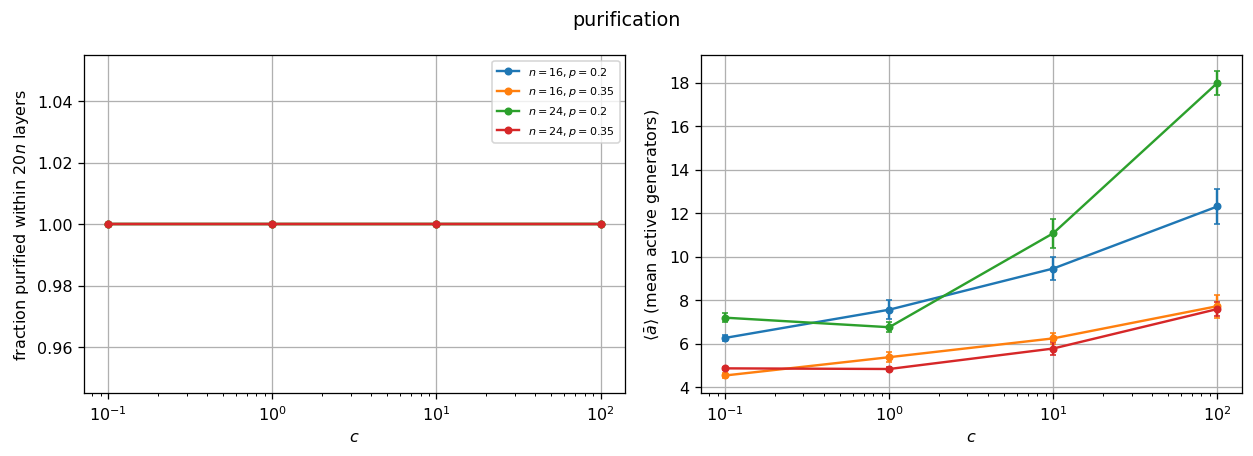

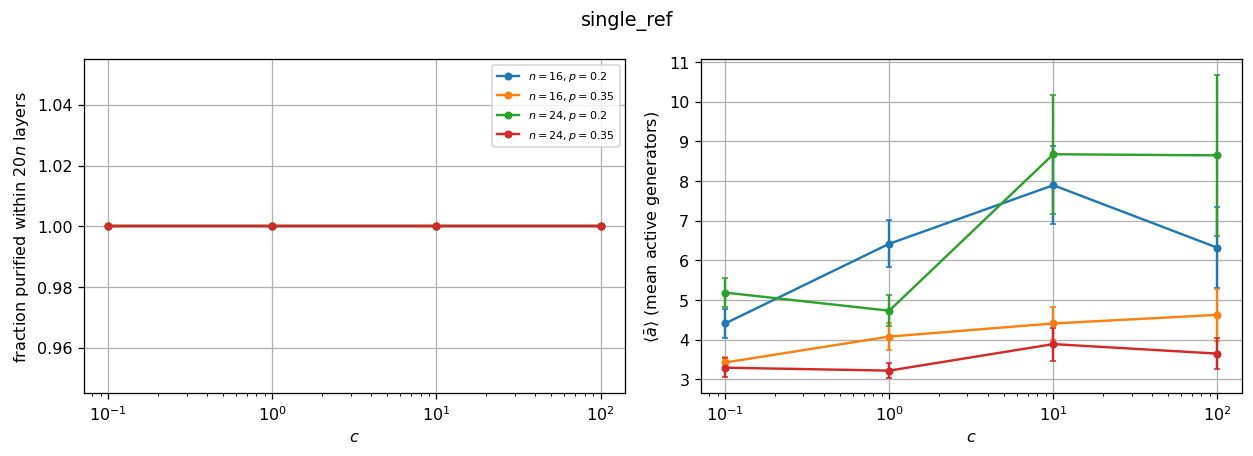

In [6]:
for pic in PICTURES:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
    sub_pic = agg[agg["picture"] == pic]
    for (n_val, p), sub in sub_pic.groupby(["n", "p"]):
        a1.plot(sub["c"], sub["frac_purified"], marker="o", ms=4,
                label=f"$n={n_val}, p={p}$")
        a2.errorbar(sub["c"], sub["mean_abar"], yerr=sub["sem_abar"],
                    marker="o", ms=4, capsize=2)
    a1.set(xscale="log", xlabel="$c$",
           ylabel=f"fraction purified within {DEPTH_FACTOR}$n$ layers")
    a1.legend(fontsize=7)
    a2.set(xscale="log", xlabel="$c$",
           ylabel=r"$\langle\bar a\rangle$ (mean active generators)")
    fig.suptitle(pic)
    fig.tight_layout(); fig.savefig(FIG / f"frac_abar_vs_c_{pic}.png"); plt.show()


## 6. Full vs single at the largest $n$, and the paper numbers


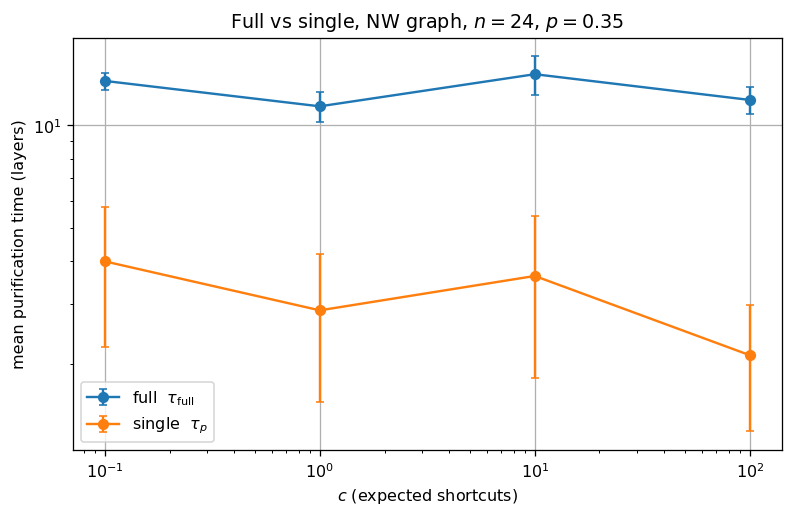

censoring (fraction purified), purification picture:
n       16        24     
p     0.20 0.35 0.20 0.35
c                        
0.1    1.0  1.0  1.0  1.0
1.0    1.0  1.0  1.0  1.0
10.0   1.0  1.0  1.0  1.0
100.0  1.0  1.0  1.0  1.0

figures -> runs/newman_watts_c/figures
aggregate -> runs/newman_watts_c/aggregate.csv


In [7]:
n_big = N_VALS[-1]
p_mid = P_VALS[len(P_VALS) // 2]
fig, ax = plt.subplots(figsize=(7, 4.6))
for pic, lab, col in [("purification", r"full  $\tau_\mathrm{full}$", "C0"),
                      ("single_ref", r"single  $\tau_p$", "C1")]:
    sub = agg[(agg["picture"] == pic) & (agg["n"] == n_big)
              & (agg["p"] == p_mid) & agg["mean_tau"].notna()]
    ax.errorbar(sub["c"], sub["mean_tau"], yerr=sub["sem_tau"], marker="o",
                capsize=2.5, color=col, label=lab)
ax.set(xscale="log", yscale="log", xlabel="$c$ (expected shortcuts)",
       ylabel="mean purification time (layers)",
       title=f"Full vs single, NW graph, $n={n_big}$, $p={p_mid}$")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "full_vs_single_vs_c.png"); plt.show()

print("censoring (fraction purified), purification picture:")
print(agg[agg["picture"] == "purification"]
      .pivot_table(index="c", columns=["n", "p"], values="frac_purified").round(2))
print(f"\nfigures -> {FIG.resolve()}\naggregate -> {(OUT / 'aggregate.csv').resolve()}")


## Checklist

- [ ] Smoke pass (`PRODUCTION = False`) clean end to end.
- [ ] Clamp table reviewed: points with `!` are complete-graph saturated, not NW.
- [ ] Calibration projection acceptable; tuned `N_GRAPHS`/`SEEDS`/`C_VALS` if not.
- [ ] `PRODUCTION = True` completed/resumed; `aggregate.csv` + `figures/` are the artifacts.
- Reproducibility: realization `gsK` = graph seed `K`; a trajectory is fixed by
  `(n, c, graph seed, p, sample_seed)`. Raise `SEEDS`/`N_GRAPHS` and delete a
  chunk folder to extend it.
